# Sprite generation for the Ice-Cream Truck game

General imports and definitions:

In [1]:
from PIL import Image, ImageColor
import numpy as np


def tint_greyscale_pixels(
    img: Image,
    color: str,
    should_tint_black: bool = True,
    threshold_shade_of_grey: float = 100.0,
    threshold_deviation_from_grey: float = 35.0,
    linear_beta: tuple = (0.8, 1.05),
) -> Image:

    rgb_color = ImageColor.getrgb(color)

    img_arr = np.array(img)
    norm_greyscale_img_arr = img_arr[:, :, :3].mean(2) / 255
    if should_tint_black:
        greyscale_mask = (img_arr[:, :, :3].std(2) <= threshold_deviation_from_grey) & (
            img_arr[:, :, :3].mean(2) <= threshold_shade_of_grey
        )
    else:
        greyscale_mask = (img_arr[:, :, :3].std(2) <= threshold_deviation_from_grey) & (
            img_arr[:, :, :3].mean(2) > threshold_shade_of_grey
        )

    delta, factor = linear_beta
    for dim, color_band in enumerate(rgb_color):
        img_arr[greyscale_mask, dim] = np.clip(
            (norm_greyscale_img_arr[greyscale_mask] + delta) * color_band * factor, 0, 255
        )

    img_arr = np.clip(img_arr, 0, 255)

    return Image.fromarray(img_arr.astype(np.uint8))

# Creating the Title Image

imports

In [2]:
from PIL import Image, ImageOps, ImageEnhance, ImageMorph
from pathlib import Path
from random import choice, uniform, gauss

We'll be using popsicles and big cats (over some simple background). We'll need blue, red and yellow cats, and popsicles of "all colors":

deepskyblue


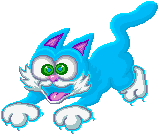

crimson


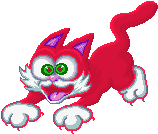

gold


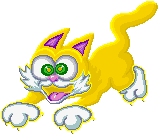

darkturquoise


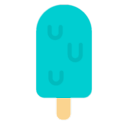

crimson


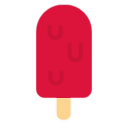

darkgoldenrod


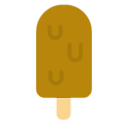

In [3]:
MAIN_IMAGES_PATH = Path("D:/MEGA/Programming/games/ice_cream_truck/ice_cream_truck/assets/images")
# should_save = True
should_save = False


big_black_cat_img = Image.open(MAIN_IMAGES_PATH / "cat" / "big_tile_image1.png")
player_colors = ("deepskyblue", "crimson", "gold")
cat_img_dict = {color: tint_greyscale_pixels(big_black_cat_img, color) for color in player_colors}

white_pop_img = Image.open(MAIN_IMAGES_PATH / "items" / "popsicleWhite.png")
popsicle_colors = ("darkturquoise", "crimson", "darkgoldenrod")
pop_img_dict = {
    color: tint_greyscale_pixels(
        white_pop_img,
        color,
        should_tint_black=False,
        threshold_deviation_from_grey=10,
        linear_beta=(0, 1),
    )
    for color in popsicle_colors
}

# TEST
for key, val in cat_img_dict.items():
    print(key)
    display(val)

for key, val in pop_img_dict.items():
    print(key)
    display(val)

Now, lets create a uniform background image of the right size, and fill it with the above images.

First, create a large image of solid background color, and fill it with popsicles:

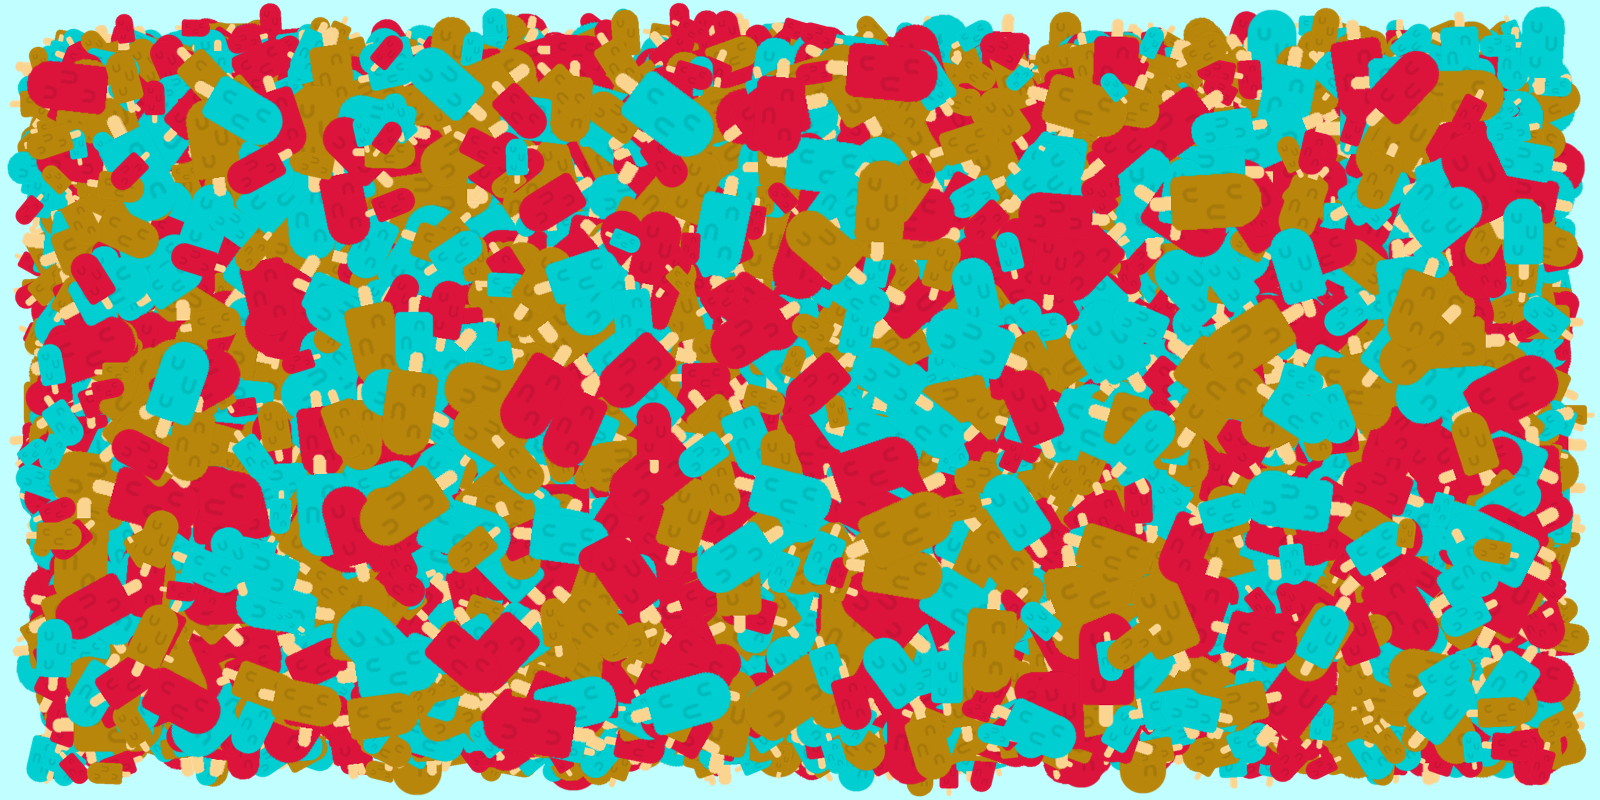

In [4]:
# create large background image
bg_image = Image.new("RGBA", (1600, 800), (193, 254, 255))

# place the popsicles, randomly:
n_pops = int(1e4)
for i in range(n_pops):
    new_pop = pop_img_dict[choice(popsicle_colors)].rotate(uniform(0, 360), expand=True)
    new_pop = ImageOps.scale(new_pop, uniform(0.3, 1))
    w_pop, h_pop = new_pop.size
    w, h = bg_image.size
    w_center, h_center = (w - w_pop) / 2, (h - h_pop) / 2
    w_pos = -1
    h_pos = -1
    while w_pos < 0 or w_pos > w - w_pop:
        w_pos = int(uniform(0, w - w_pop))
    while h_pos < 0 or h_pos > h - h_pop:
        h_pos = int(uniform(0, w - h_pop))

    bg_image.alpha_composite(new_pop, dest=(w_pos, h_pos))

# TEST
display(bg_image)

Reduce the brightness so that the cats will stand out

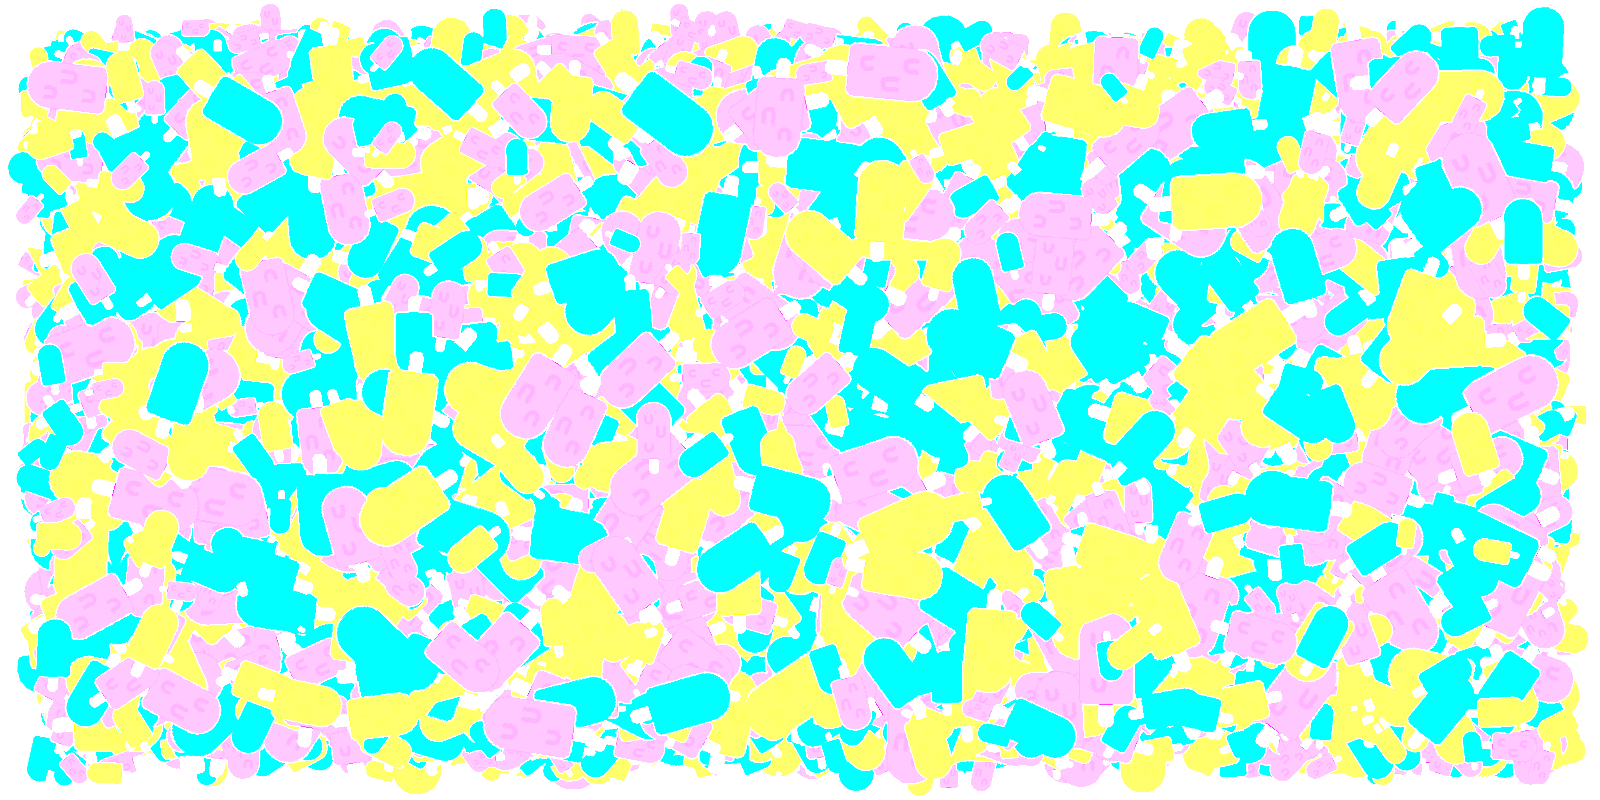

In [5]:
enhancer = ImageEnhance.Brightness(bg_image)

factor = 10
bright_bg_image = enhancer.enhance(factor)

# should_save = True
should_save = False

if should_save:
    bright_bg_image.save(MAIN_IMAGES_PATH / "instructions_image.png")
    print(f"saved as {MAIN_IMAGES_PATH / 'instructions_image.png'}")

# TEST
display(bright_bg_image)

Place the cats on top:

In [6]:
def get_aura_image(img, color_str):
    """Takes an input PIL image and adds an 'aura' effect to it in chosen color"""

    _, _, _, alpha_chan = img.split()

    dilate_op = ImageMorph.MorphOp(op_name="dilation8")
    _, dilated_alpha_chan = dilate_op.apply(alpha_chan)
    _, dilated_alpha_chan = dilate_op.apply(dilated_alpha_chan)
    _, dilated_alpha_chan = dilate_op.apply(dilated_alpha_chan)

    white_aura_img = dilated_alpha_chan.convert("RGBA")
    white_aura_img.putalpha(dilated_alpha_chan)

    blue_aura_img = tint_greyscale_pixels(
        white_aura_img,
        color_str,
        should_tint_black=False,
        threshold_deviation_from_grey=10,
        linear_beta=(0, 1),
    )

    return Image.alpha_composite(blue_aura_img, img)

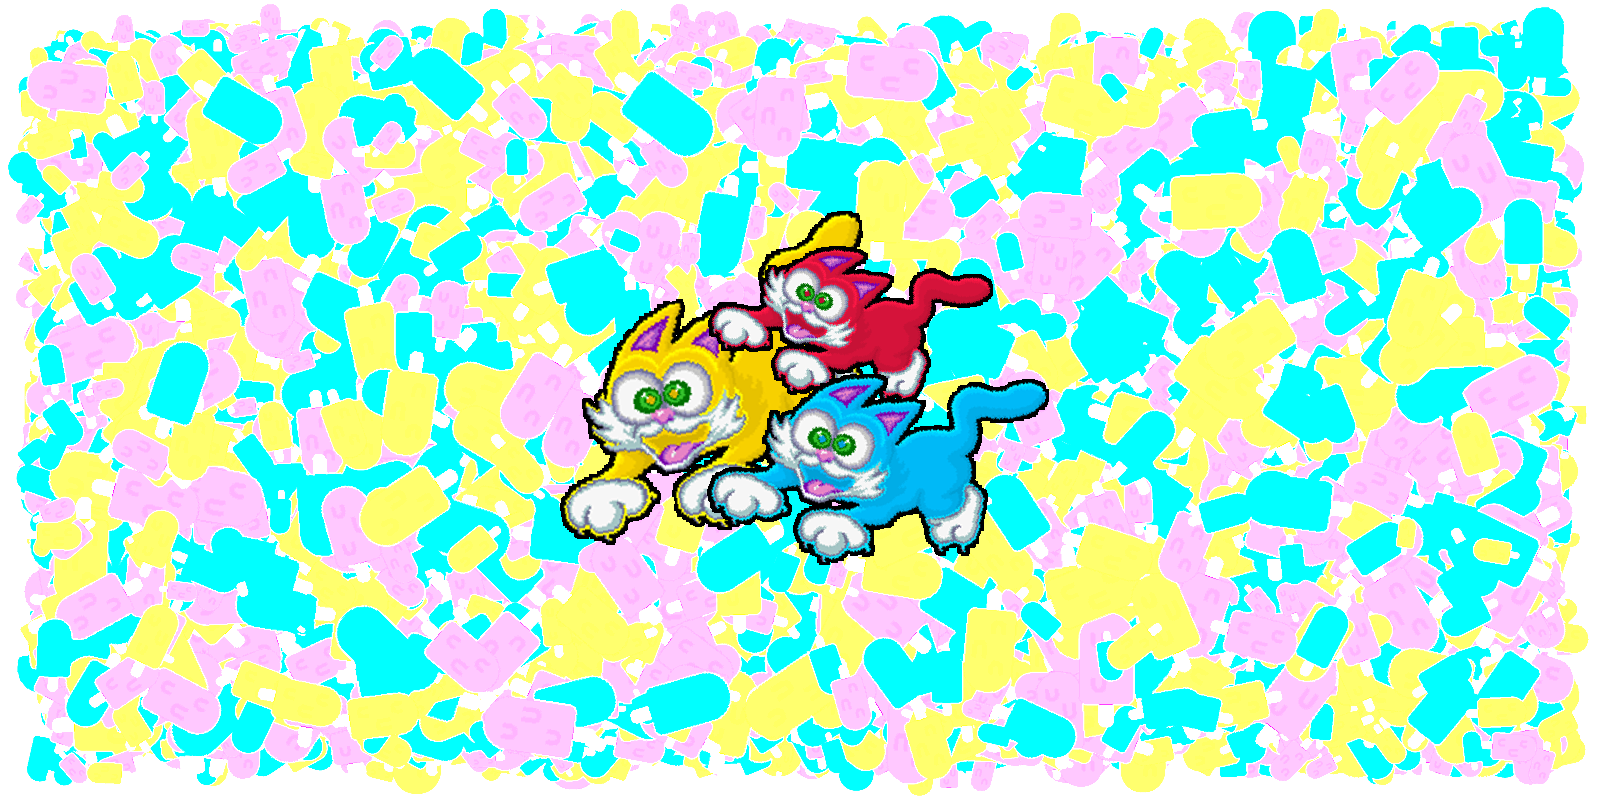

In [7]:
title_image = bright_bg_image.copy()

f = 0.9
blue_cat_img = get_aura_image(
    ImageOps.scale(cat_img_dict["deepskyblue"], 2 * f).rotate(-20, expand=True), "black"
)
red_cat_img = get_aura_image(
    ImageOps.scale(cat_img_dict["crimson"], 1.6 * f).rotate(-30, expand=True), "black"
)
yellow_cat_img = get_aura_image(
    ImageOps.scale(cat_img_dict["gold"], 2.4 * f).rotate(10, expand=True), "black"
)

title_image.alpha_composite(yellow_cat_img, dest=(520, 210))
title_image.alpha_composite(red_cat_img, dest=(700, 170))
title_image.alpha_composite(blue_cat_img, dest=(700, 290))


# TEST
display(title_image)

save it:

In [8]:
if should_save:
    title_image.save(MAIN_IMAGES_PATH / "title_image.png")
    print(f"saved as {MAIN_IMAGES_PATH / 'title_image.png'}")

# Extracting Sprites from Spritesheet

Imports

In [9]:
from pathlib import Path
from typing import List

import numpy as np
from PIL import Image

Loading the spreadsheet

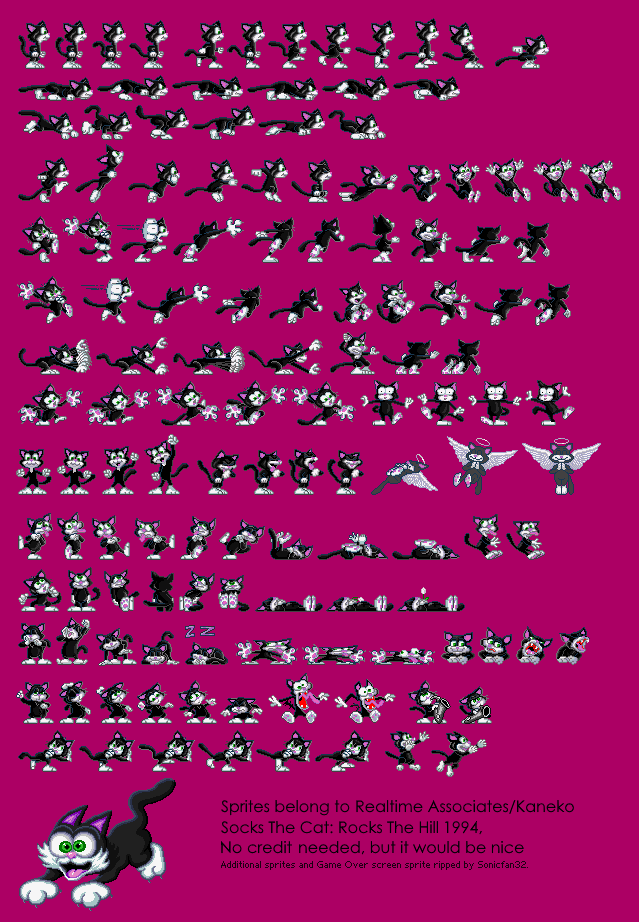

In [10]:
DIR_PATH = MAIN_IMAGES_PATH / "cat/source"
IMG_PATH = DIR_PATH / "SNES - Socks the Cat Rocks the Hill Prototype - Socks The Cat.png"

spritesheet_img = Image.open(IMG_PATH)

# TEST
display(spritesheet_img)

Find the transparent color, for later:

In [11]:
transparent_color = spritesheet_img.getpixel((0, 0))

Also, lets create a function for making a background color transparent

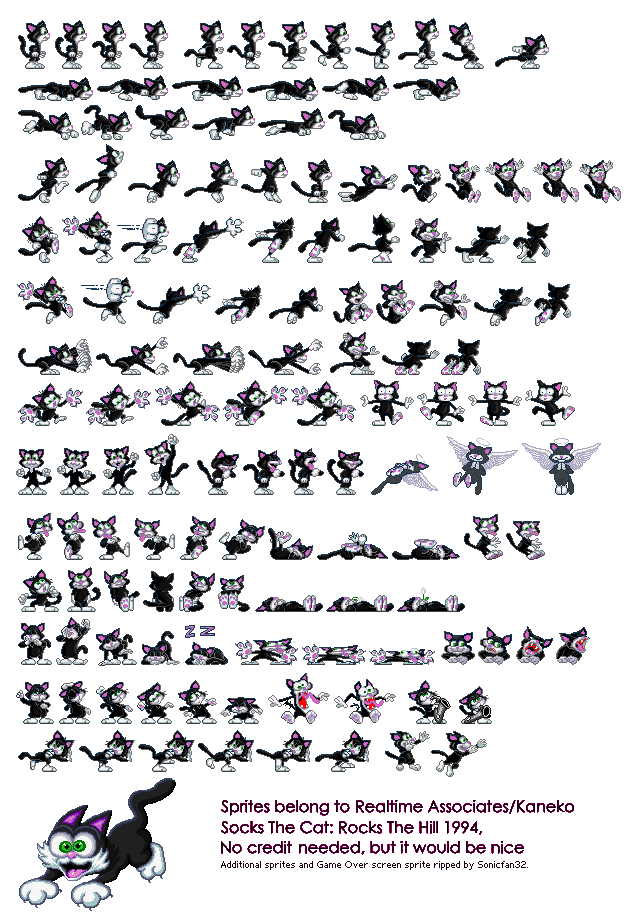

In [12]:
def make_color_transparent(rgb_img: Image.Image, color) -> Image.Image:
    """
    Accepts an RGB image and returns an RGBA image with the alphas set to 0 where the pixels are of color 'color'
    Adapted from:
    https://stackoverflow.com/questions/3752476/python-pil-replace-a-single-rgba-color
    """

    rgba_img = rgb_img.convert("RGBA")

    arr = np.array(rgba_img)

    red, green, blue = color
    red_arr, green_arr, blue_arr, alpha_arr = arr.T

    # Replace white with red... (leaves alpha values alone...)
    color_areas = (red_arr == red) & (green_arr == green) & (blue_arr == blue)

    arr[:, :, 3][color_areas.T] = 0  # Transpose back needed

    return Image.fromarray(arr)


# TEST
make_color_transparent(spritesheet_img, transparent_color)

Now for the hard part - I wish to split the sprite-sheet into seperate sprites in the following way. I would like to have, in the end, a list of all sprites (later I could manually make it into a dictionary) from the top left to the bottom right, along the rows.

One idea (drawn from just examining this specific spritesheet, which came without any coordinates) is to first crop it into strips, then crop each strip into rectangles.

Begin by getting coordinates of rows containing solely the 'transparent' color found above

In [13]:
arr_img = np.array(spritesheet_img)

bg_color_rows = []
column_rgb = np.tile(transparent_color, (arr_img.shape[1], 1))

for row_idx in range(arr_img.shape[0]):
    if (arr_img[row_idx, :, :] == column_rgb).all():
        bg_color_rows.append(row_idx)

# TEST
print("Background-color row indices:\n")
[print(row_idx, end=", ") for row_idx in bg_color_rows];

Background-color row indices:

0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 69, 70, 71, 72, 73, 74, 101, 102, 103, 104, 140, 141, 142, 143, 203, 204, 205, 206, 207, 208, 209, 210, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 326, 327, 328, 329, 330, 331, 375, 376, 377, 378, 379, 426, 427, 428, 429, 430, 431, 432, 433, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 560, 561, 562, 563, 564, 565, 566, 612, 613, 614, 615, 616, 666, 667, 668, 669, 670, 671, 672, 724, 725, 726, 727, 728, 729, 777, 911, 912, 913, 914, 915, 916, 917, 918, 919, 920, 921, 

Then, keep edges of the gaps (which are caused by the sprites) in a list of tuples:

In [14]:
row_crop_coords = []
for idx in range(len(bg_color_rows)):
    if bg_color_rows[idx] - bg_color_rows[idx - 1] > 1:
        row_crop_coords.append((bg_color_rows[idx - 1], bg_color_rows[idx]))

# TEST
print("Row crop coordinates:\n")
print(row_crop_coords)

Row crop coordinates:

[(17, 69), (74, 101), (104, 140), (143, 203), (210, 263), (275, 326), (331, 375), (379, 426), (433, 495), (511, 560), (566, 612), (616, 666), (672, 724), (729, 777), (777, 911)]


Now, cut the spritesheet into strips

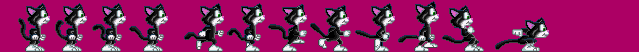

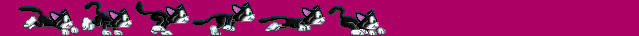

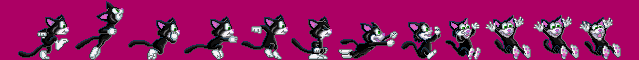

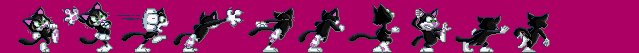

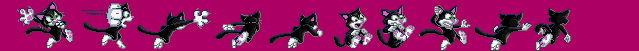

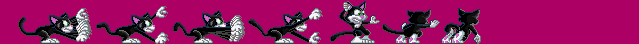

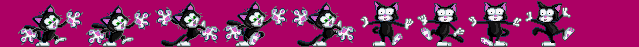

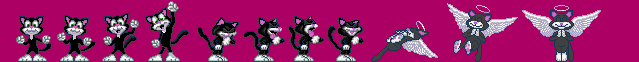

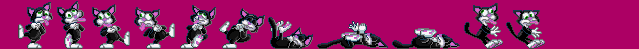

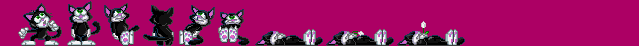

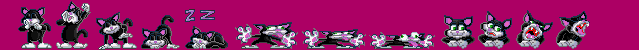

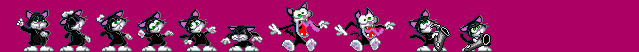

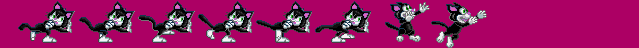

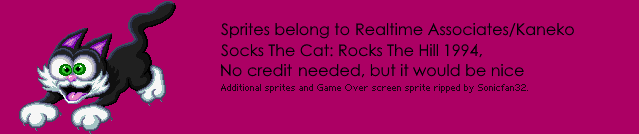

In [15]:
# pop_w = popsicle_img.width
# pop_h = popsicle_img.height
# f = 0.77

# stick_img = popsicle_img.crop((0, pop_h * f, pop_w, pop_h))

width = spritesheet_img.width
sprite_strips = []
for h_coord_1, h_coord_2 in row_crop_coords:
    strip = spritesheet_img.crop((0, h_coord_1, width, h_coord_2))
    sprite_strips.append(strip)

# TEST
[display(strip) for strip in sprite_strips];

Great. Now, lets do basically the same for each strip. But first, let's turn the above script into a function:

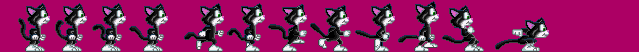

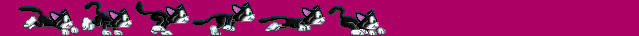

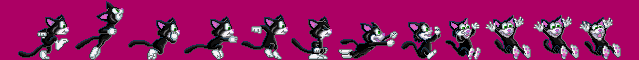

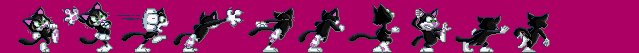

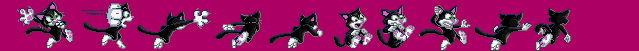

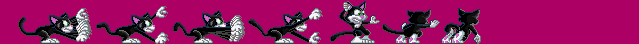

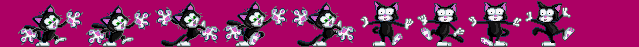

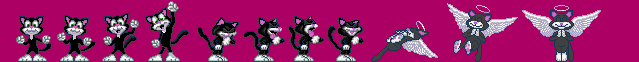

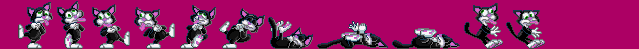

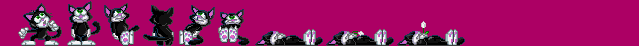

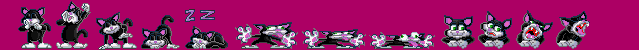

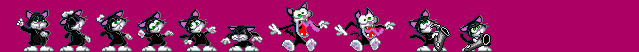

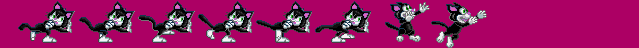

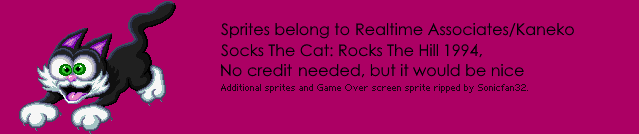

In [16]:
def split_spritesheet_to_strips(img: Image.Image, bg_color) -> List[Image.Image]:
    """Accept an RBG PIL.Image and a background color and split it into strips"""

    arr_img = np.array(img)

    column_rgb_bg_color = np.tile(bg_color, (arr_img.shape[1], 1))

    bg_color_rows = []
    for row_idx in range(arr_img.shape[0]):
        if (arr_img[row_idx, :, :] == column_rgb_bg_color).all():
            bg_color_rows.append(row_idx)

    row_crop_coords = []
    for idx in range(len(bg_color_rows)):
        if bg_color_rows[idx] - bg_color_rows[idx - 1] > 1:
            row_crop_coords.append((bg_color_rows[idx - 1], bg_color_rows[idx]))

    width = img.width
    sprite_strips = []
    for h_coord_1, h_coord_2 in row_crop_coords:
        strip = img.crop((0, h_coord_1, width, h_coord_2))
        sprite_strips.append(strip)

    return sprite_strips


# TEST
[display(strip) for strip in split_spritesheet_to_strips(spritesheet_img, transparent_color)];

Now, lets use this function on transposed strips:

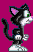

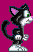

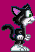

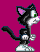

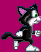

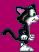

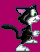

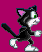

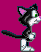

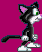

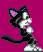

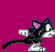

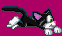

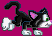

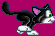

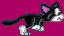

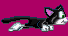

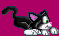

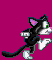

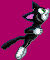

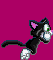

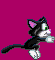

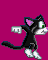

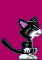

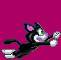

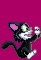

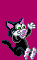

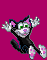

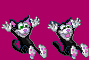

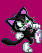

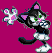

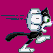

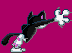

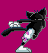

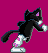

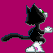

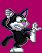

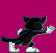

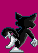

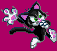

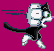

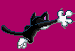

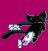

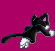

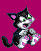

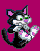

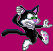

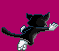

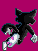

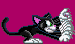

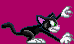

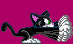

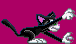

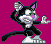

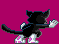

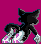

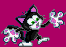

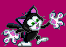

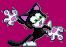

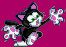

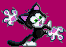

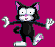

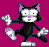

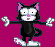

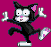

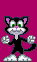

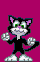

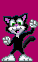

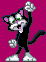

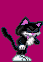

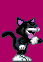

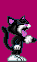

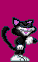

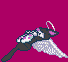

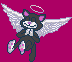

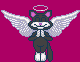

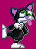

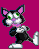

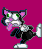

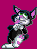

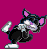

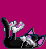

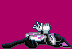

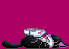

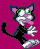

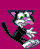

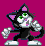

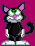

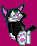

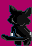

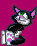

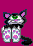

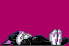

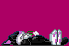

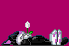

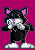

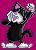

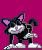

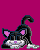

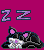

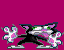

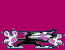

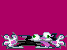

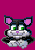

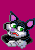

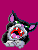

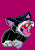

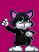

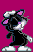

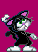

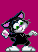

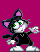

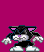

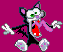

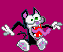

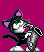

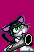

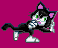

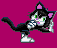

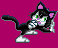

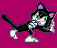

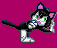

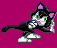

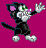

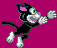

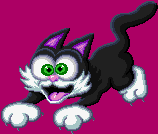

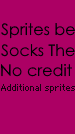

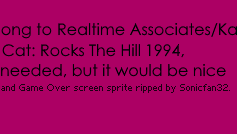

In [17]:
all_sprites = []
for strip in sprite_strips:
    transposed_strip = strip.transpose(5)
    new_sprites = [
        transposed_img.transpose(5)
        for transposed_img in split_spritesheet_to_strips(transposed_strip, transparent_color)
    ]
    all_sprites += new_sprites

# TEST
[display(sprite) for sprite in all_sprites];

Note that sprites are of varying dimensions (height x width). This could be a problem, but at least the sprites in each row are related, so they should have same height.

Lets do it again, in a single function, this time making the background color transparent:

In [18]:
def split_spritesheet(spritesheet_img, bg_color=None) -> List[Image.Image]:
    """
    Split spritesheet into single sprites.
    Spritesheet is assumed to be seperated into rows by at least 1 pixel of background.
    """

    # if background/transparent color isn't given, assume the upper left pixel is background
    if bg_color is None:
        bg_color = spritesheet_img.getpixel((0, 0))

    sprite_strips = split_spritesheet_to_strips(spritesheet_img, bg_color)

    all_sprites = []
    for strip in sprite_strips:
        transposed_strip = strip.transpose(5)
        new_sprites = [
            make_color_transparent(transposed_img.transpose(5), bg_color)
            for transposed_img in split_spritesheet_to_strips(transposed_strip, transparent_color)
        ]
        all_sprites += new_sprites

    return all_sprites

So, now we have all the sprites we could ask for. Since they are unnamed, we'll have to name them manually (according to row themes). Let's clean up the few mistakes (text in the end, and one pair which apprently had no space between them):

Got rid of:



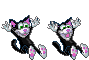

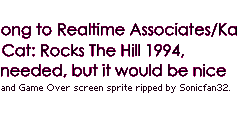

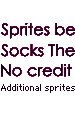

In [19]:
all_sprites = split_spritesheet(spritesheet_img, transparent_color)

trash_list = [all_sprites.pop(idx) for idx in [34] + [-1] * 6]
print("Got rid of:\n")
[display(sprite) for sprite in trash_list];

Instead of coming up with names for the many sprites which I don't need, let's choose the sprites I want to keep, (re-ordered where seems more logical) first:

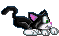

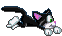

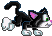

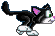

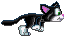

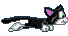

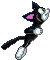

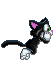

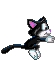

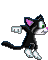

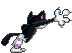

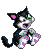

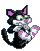

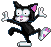

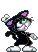

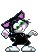

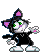

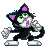

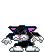

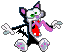

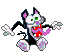

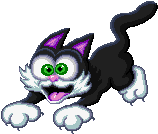

In [20]:
my_sprite_idxs = [
    12,
    23,
    18,
    19,
    20,
    21,
    22,
    25,
    26,
    27,
    28,
    37,
    49,
    50,
    69,
    115,
    116,
    117,
    92,
    118,
    119,
    120,
    -1,
]
my_sprites = [all_sprites[idx] for idx in my_sprite_idxs]

# TEST
[display(sprite) for sprite in my_sprites];

Now, to name them. We'll keep them in a dictionary where the keys are the names, and values are a list of images:

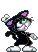

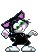

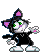

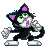

In [21]:
actions = [
    ("standing", 1),
    ("running", 6),
    ("jumping", 1),
    ("stalling", 2),
    ("falling", 1),
    ("scratching", 1),
    ("dropping", 2),
    ("getting_hit", 1),
    ("begging", 4),
    ("screaming", 3),
    ("big_tile_image", 1),
]

name_list = []
for action, n in actions:
    name_list += [action] * n

sprite_name_dict = {}
for name, sprite_img in zip(name_list, my_sprites):
    if name in sprite_name_dict:
        sprite_name_dict[name].append(sprite_img)
    else:
        sprite_name_dict[name] = [sprite_img]

# TEST
[display(img) for img in sprite_name_dict["begging"]];

And finally, we save the sprites:

In [22]:
if should_save:
    SAVEֹֹֹ_DIR_PATH = MAIN_IMAGES_PATH / "cat"
    for name, img_list in sprite_name_dict.items():
        for idx, img in enumerate(img_list):
            img.save(
                SAVEֹֹֹ_DIR_PATH / f"{name}{idx+1}.png",
            )

# Adding Color Aura to Texture

imports

In [23]:
from pathlib import Path

from PIL import ImageChops, ImageEnhance

get image of blue cat:

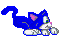

In [24]:
IMAGE_PATH = MAIN_IMAGES_PATH / "cat/running1.png"
color = "blue"

img = tint_greyscale_pixels(Image.open(IMAGE_PATH), color)

# test
display(img)

Create a blue "aura" RGBA image by dilating the alpha channel and tinting:

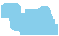

In [25]:
_, _, _, alpha_chan = img.split()

dilate_op = ImageMorph.MorphOp(op_name="dilation8")
_, dilated_alpha_chan = dilate_op.apply(alpha_chan)
_, dilated_alpha_chan = dilate_op.apply(dilated_alpha_chan)
_, dilated_alpha_chan = dilate_op.apply(dilated_alpha_chan)

white_aura_img = dilated_alpha_chan.convert("RGBA")
white_aura_img.putalpha(dilated_alpha_chan)

blue_aura_img = tint_greyscale_pixels(
    white_aura_img,
    "skyblue",
    should_tint_black=False,
    threshold_deviation_from_grey=10,
    linear_beta=(0, 1),
)

# test
display(blue_aura_img)

Composite the aura and the original image:

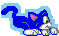

In [26]:
aura_img = Image.alpha_composite(blue_aura_img, img)

# test
display(aura_img)

# Creating a "Heart Popsicle"

imports

from pathlib import Path

import numpy as np

In [27]:
from PIL import Image, ImageColor, ImageDraw, ImageFilter, ImageMorph, ImageOps

MAIN_PATH = MAIN_IMAGES_PATH

load a heart image and a popsicle image, painting the popsicle red for clarity:

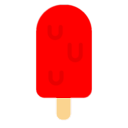

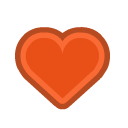

In [28]:
POP_PATH = MAIN_PATH / "items" / "popsicleWhite.png"
HEART_PATH = MAIN_PATH / "HUD" / "hudHeart_full.png"

heart_img = Image.open(HEART_PATH)
popsicle_img = Image.open(POP_PATH)

popsicle_img = tint_greyscale_pixels(
    popsicle_img,
    "red",
    should_tint_black=False,
    threshold_deviation_from_grey=10,
    linear_beta=(0, 1),
)

# test
display(popsicle_img)
display(heart_img)

take the posicle stick:

C:\Users\Idom\AppData\Local\Temp\ipykernel_29644\3019206981.py:8: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  display(ImageOps.scale(stick_img, 4, Image.BOX))


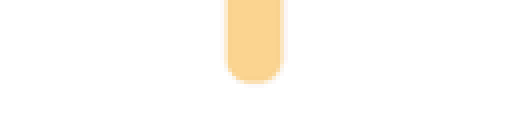

In [29]:
pop_w = popsicle_img.width
pop_h = popsicle_img.height
f = 0.77

stick_img = popsicle_img.crop((0, pop_h * f, pop_w, pop_h))

# test
display(ImageOps.scale(stick_img, 4, Image.BOX))

split the stick end from the straight part

Stick end:


C:\Users\Idom\AppData\Local\Temp\ipykernel_29644\226304293.py:10: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  display(ImageOps.scale(stick_end_img, 4, Image.BOX))


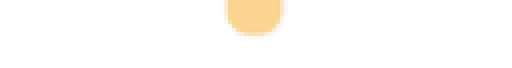

Straight part:


C:\Users\Idom\AppData\Local\Temp\ipykernel_29644\226304293.py:12: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  display(ImageOps.scale(stick_straight_img, 4, Image.BOX))


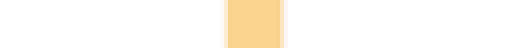

In [30]:
stick_w = stick_img.width
stick_h = stick_img.height
f = 0.4

stick_end_img = stick_img.crop((0, stick_h * f, stick_w, stick_h))
stick_straight_img = stick_img.crop((0, 0, stick_w, stick_h * f))

# test
print("Stick end:")
display(ImageOps.scale(stick_end_img, 4, Image.BOX))
print("Straight part:")
display(ImageOps.scale(stick_straight_img, 4, Image.BOX))

Now build a longer stick

C:\Users\Idom\AppData\Local\Temp\ipykernel_29644\4110876514.py:38: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  display(ImageOps.scale(long_stick_img, 4, Image.BOX))


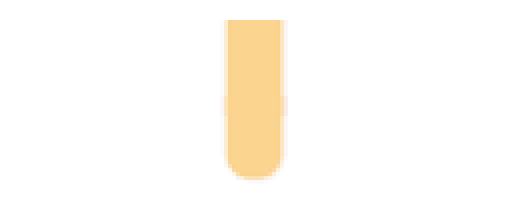

In [31]:
def concat_list_v(img_list, overlap_pxls_list=None, h_disp_list=None, top_last=True):
    """Adapted from https://note.nkmk.me/en/python-pillow-concat-images/"""

    if overlap_pxls_list is None:
        overlap_pxls_list = [0] * len(img_list)

    if h_disp_list is None:
        h_disp_list = [0] * len(img_list)

    dst = Image.new(
        "RGBA",
        (
            max([img.width for img in img_list]),
            sum([img.height for img in img_list]) - sum(overlap_pxls_list),
        ),
    )

    if top_last:
        img_list = list(reversed([ImageOps.flip(img) for img in img_list]))

    for idx, img in enumerate(img_list):
        if idx == 0:
            dst.alpha_composite(img, (h_disp_list[idx], 0))
        else:
            dst.alpha_composite(
                img, (h_disp_list[idx], idx * img_list[idx - 1].height - overlap_pxls_list[idx - 1])
            )

    if top_last:
        dst = ImageOps.flip(dst)

    return dst


long_stick_img = concat_list_v([stick_straight_img] * 3 + [stick_end_img])

# test
display(ImageOps.scale(long_stick_img, 4, Image.BOX))

Now to put a heart on the stick, and save:

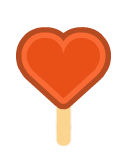

In [32]:
heart_popsicle = concat_list_v([heart_img, long_stick_img], [27, 0], [0, 1])

if should_save:
    heart_popsicle.save(
        MAIN_PATH / "items" / "popsicleHeart.png",
    )

# test
display(heart_popsicle)

# Melting popsicles animation:

imports

from pathlib import Path

import numpy as np

In [33]:
from PIL import Image, ImageColor, ImageDraw, ImageFilter, ImageMorph, ImageOps

MAIN_PATH = MAIN_IMAGES_PATH / "items"
WHITE_POP_PATH = MAIN_PATH / "popsicleWhite.png"

Create a red popsicle to better view the process

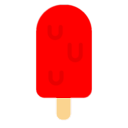

In [34]:
white_pop_img = Image.open(WHITE_POP_PATH)

red_pop_img = tint_greyscale_pixels(
    white_pop_img,
    "red",
    should_tint_black=False,
    threshold_deviation_from_grey=10,
    linear_beta=(0, 1),
)

# test
display(red_pop_img)

Create a "melting" animation by increasingly cropping the top of the image:

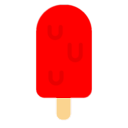

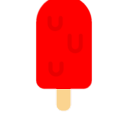

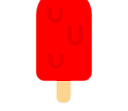

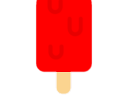

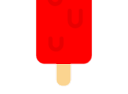

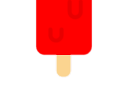

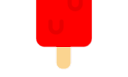

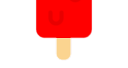

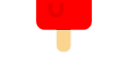

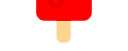

In [35]:
w = red_pop_img.width
h = red_pop_img.height
red_pop_img.crop((0, h * 0.1, h, w))

red_pop_melting_images = [
    red_pop_img.crop((0, h * factor, h, w)) for factor in np.linspace(0, 0.60, 10)
]

# test
for img in red_pop_melting_images:
    display(img)

A problem - a cropped picture is smaller, and so when re-centered it changes position. Instead of cropping I should try making the top transparent:

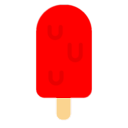

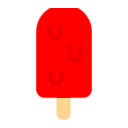

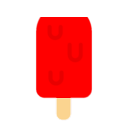

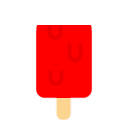

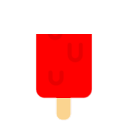

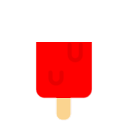

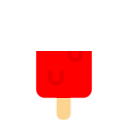

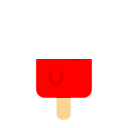

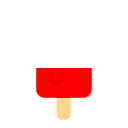

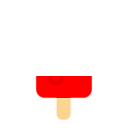

In [36]:
w = red_pop_img.width
h = red_pop_img.height
arr_img = np.array(red_pop_img)

red_pop_melting_images = []
for factor in np.linspace(0, 0.60, 10):
    arr_img = np.array(red_pop_img)
    arr_img[: int(h * factor), :, 3] = 0
    red_pop_melting_images.append(Image.fromarray(arr_img))

# test
for img in red_pop_melting_images:
    display(img)

Perhaps I should make the melting look more realistic:

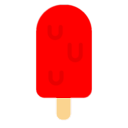

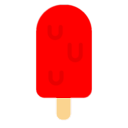

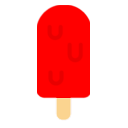

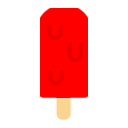

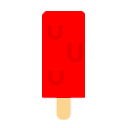

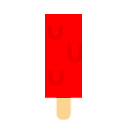

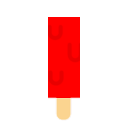

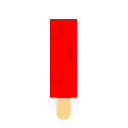

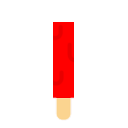

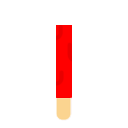

In [37]:
w = red_pop_img.width
h = red_pop_img.height
arr_img = np.array(red_pop_img)

red_pop_melting_images = []
for x_factor, y_factor in zip(np.linspace(0.5, 0.875, 10), np.linspace(0, 0.2, 10)):
    arr_img = np.array(red_pop_img)
    arr_img[: int(h * y_factor), :, 3] = 0
    arr_img[:, : int(w / 2 * x_factor), 3] = 0
    arr_img[:, int(w * (1 - x_factor / 2)) :, 3] = 0
    red_pop_melting_images.append(Image.fromarray(arr_img))

# test
for img in red_pop_melting_images:
    display(img)

# Creating colorful popcicles by tinting a white one:

imports

from pathlib import Path

import numpy as np

In [38]:
from PIL import Image, ImageColor, ImageDraw, ImageFilter, ImageMorph, ImageOps

MAIN_PATH = MAIN_IMAGES_PATH / "items"
WHITE_POP_PATH = MAIN_PATH / "popsicleWhite.png"

Loading the white popsicle

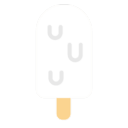

In [39]:
white_pop_img = Image.open(WHITE_POP_PATH)

# test
display(white_pop_img)

Tinting:

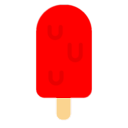

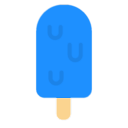

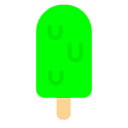

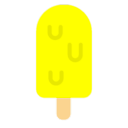

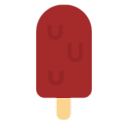

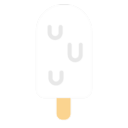

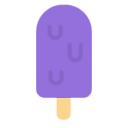

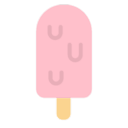

In [40]:
for color in ["red", "dodgerblue", "lime", "yellow", "brown", "white", "mediumpurple", "pink"]:
    display(
        tint_greyscale_pixels(
            white_pop_img,
            color,
            should_tint_black=False,
            threshold_deviation_from_grey=10,
            linear_beta=(0, 1),
        )
    )

# Fixing a "poof" GIF transparency:

Imports:

In [41]:
from PIL import Image, ImageDraw, ImageFilter, ImageMorph, ImageOps
from contextlib import contextmanager
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path

MAIN_PATH = MAIN_IMAGES_PATH / "gifs"
GIF_PATH = MAIN_PATH / "poof.gif"

Loading the gif and turning into a list of PIL images:

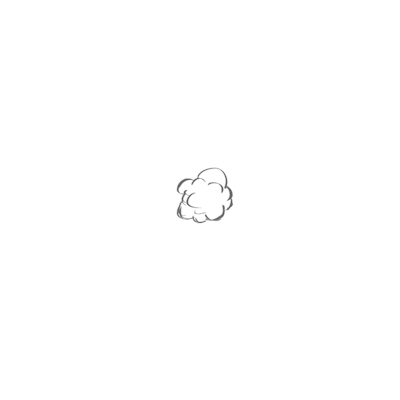

for 70 (UNITS?)


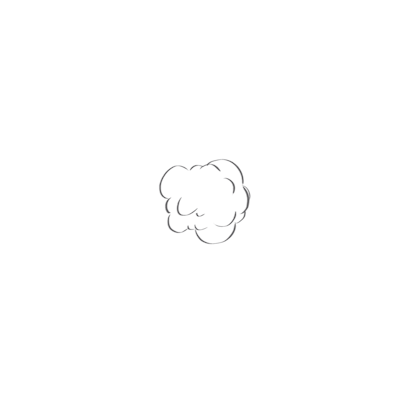

for 70 (UNITS?)


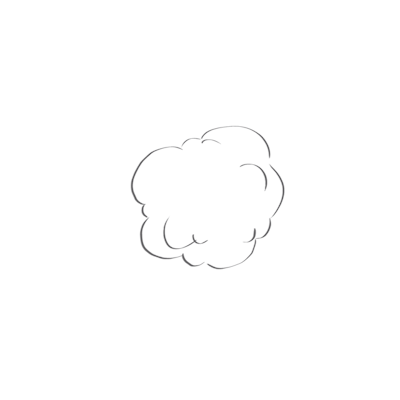

for 70 (UNITS?)


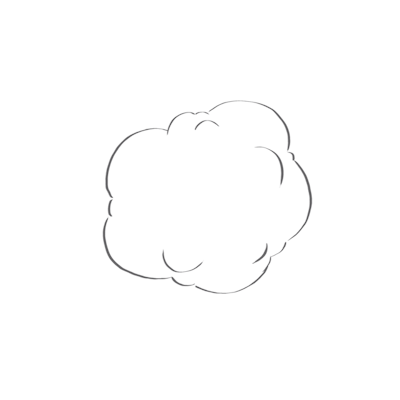

for 70 (UNITS?)


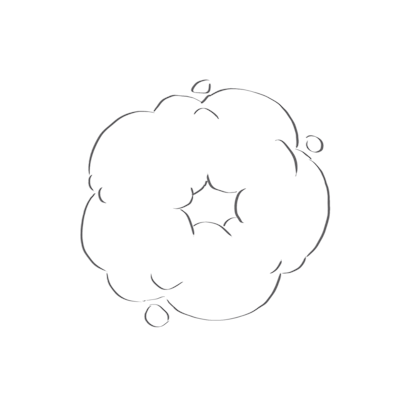

for 100 (UNITS?)


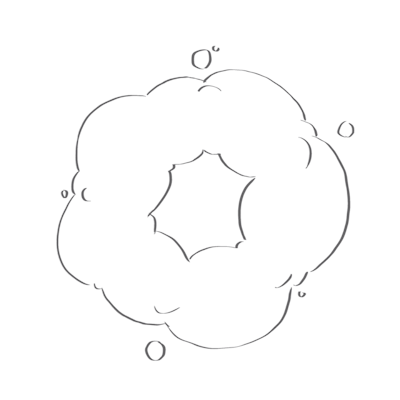

for 100 (UNITS?)


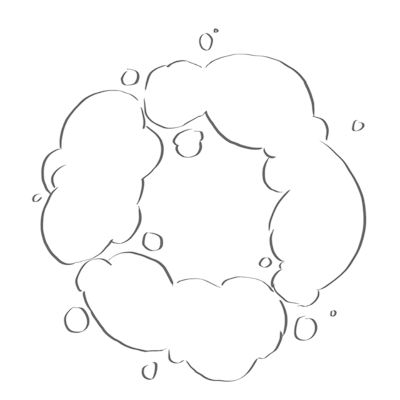

for 100 (UNITS?)


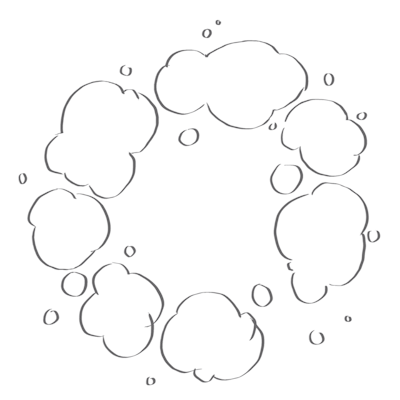

for 70 (UNITS?)


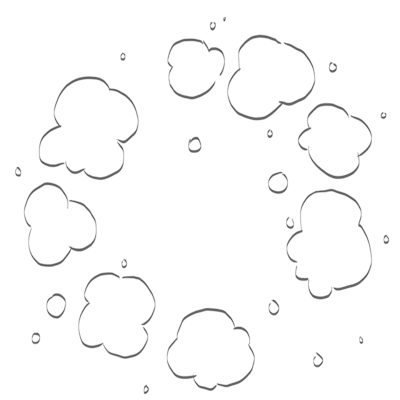

for 70 (UNITS?)


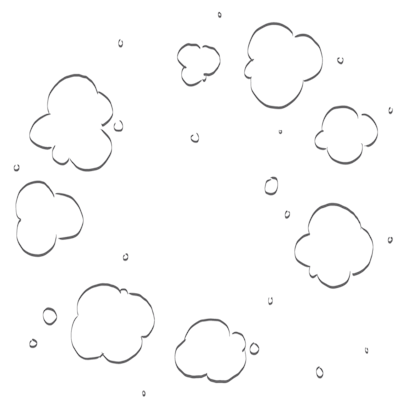

for 70 (UNITS?)


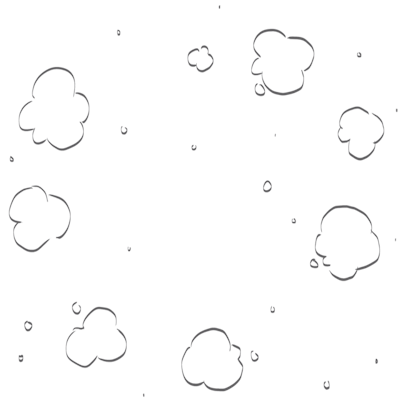

for 70 (UNITS?)


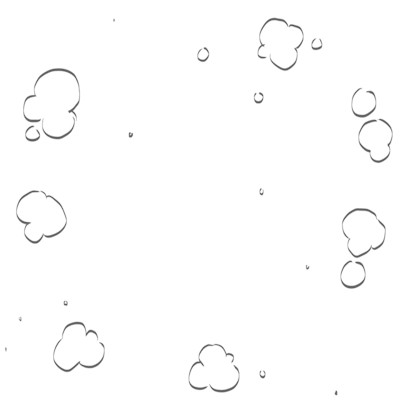

for 70 (UNITS?)


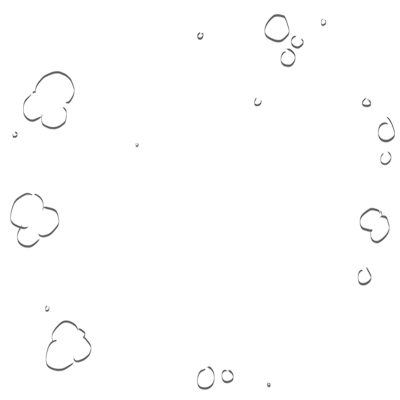

for 70 (UNITS?)


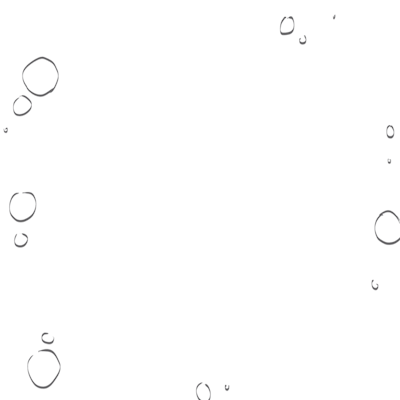

for 70 (UNITS?)


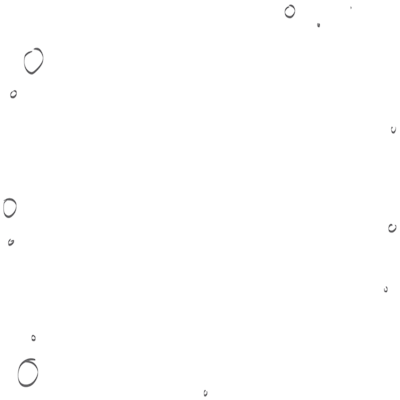

for 100 (UNITS?)


In [42]:
@dataclass
class Frame:
    image: Image
    duration: float


gif = Image.open(GIF_PATH)

frames = []
for frame in range(gif.n_frames):
    gif.seek(frame)
    frames.append(Frame(gif.convert("RGBA"), gif.info["duration"]))

# test
for frame in frames:
    display(frame.image)
    print(f"for {frame.duration} (UNITS?)")

Use filters to close slightly-open regions in every frame:

C:\Users\Idom\AppData\Local\Temp\ipykernel_29644\627140414.py:19: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  def resize_concat_horizontally(im_list, resample=Image.BOX):


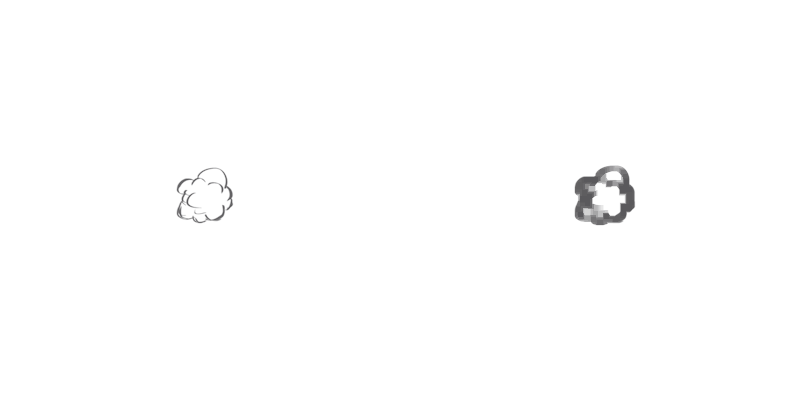

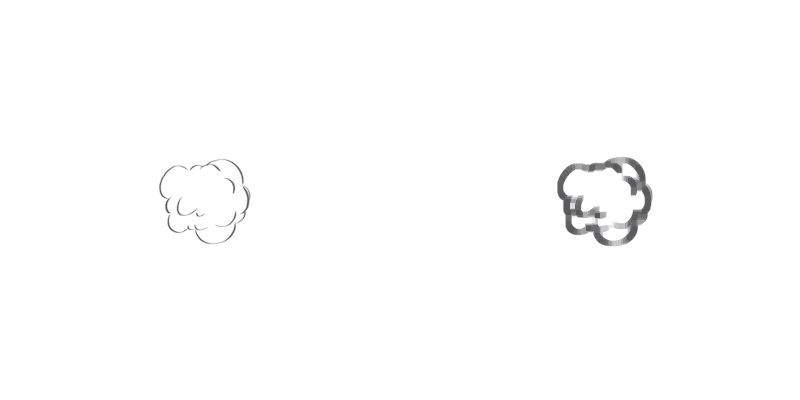

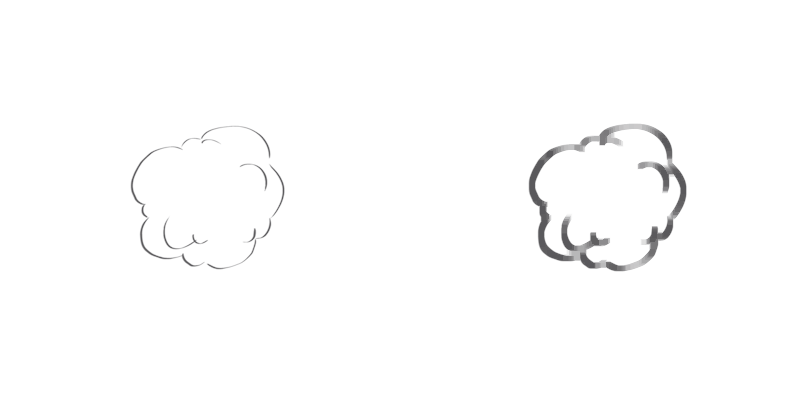

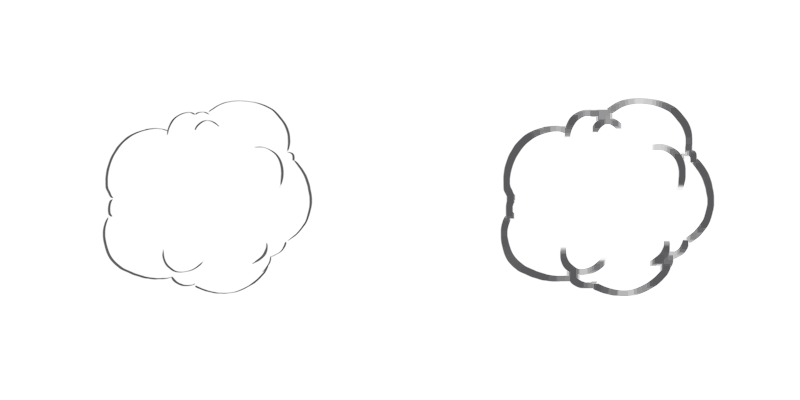

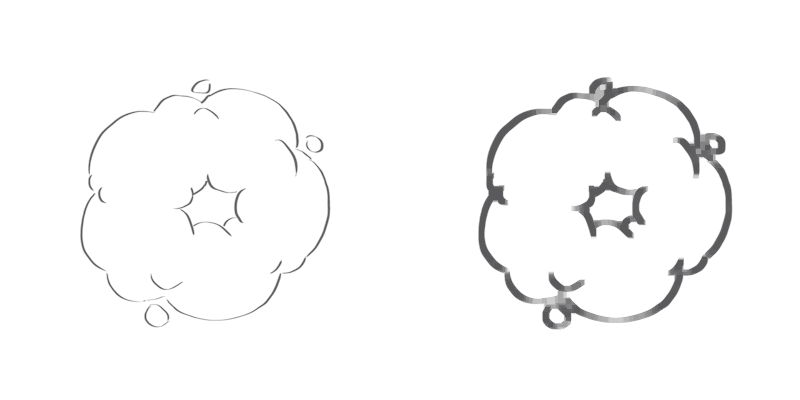

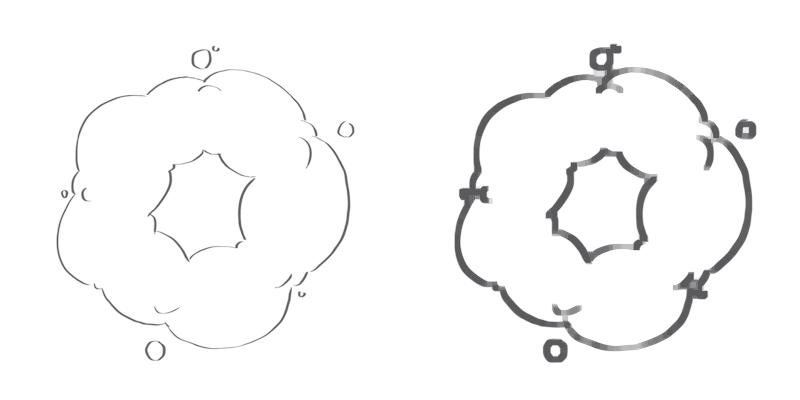

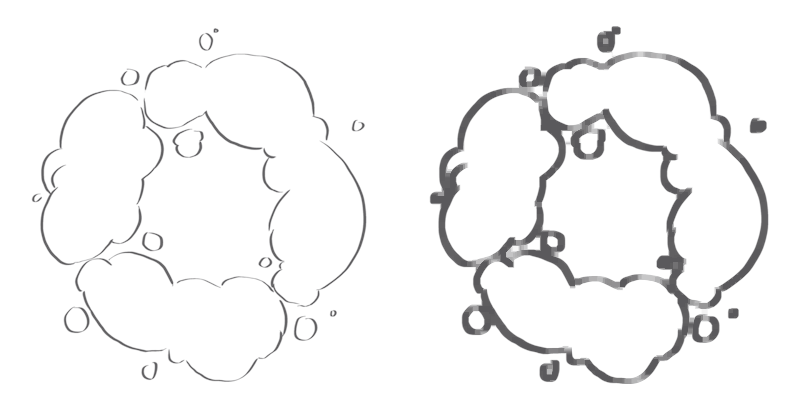

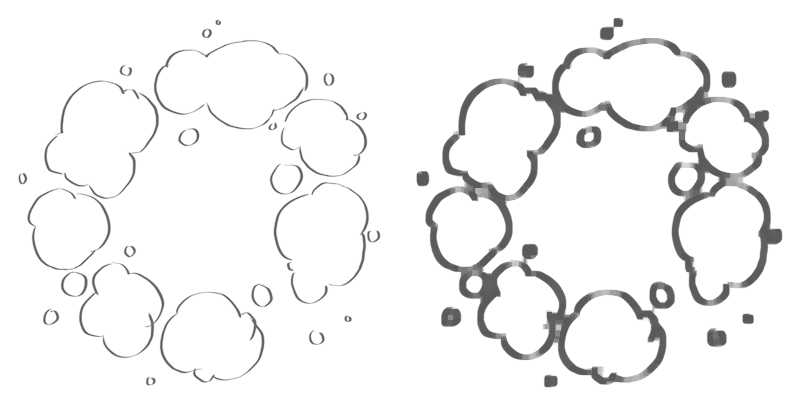

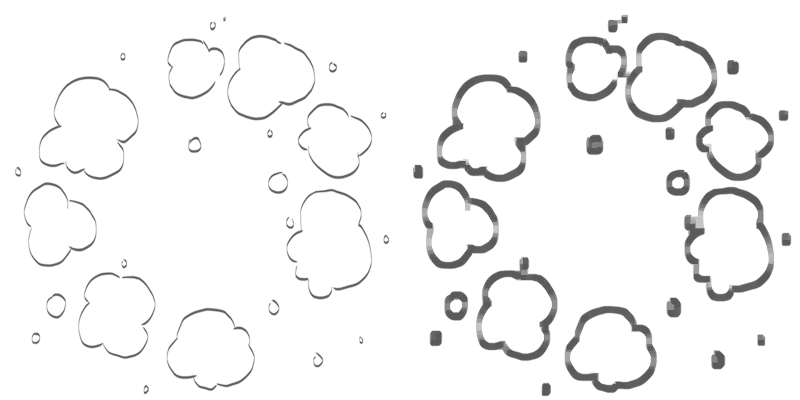

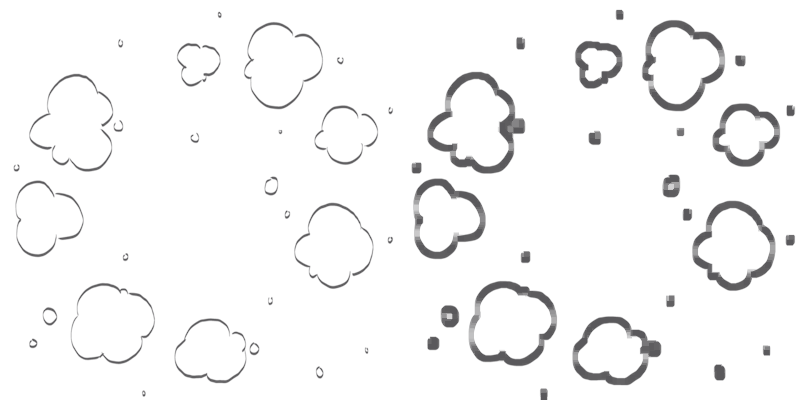

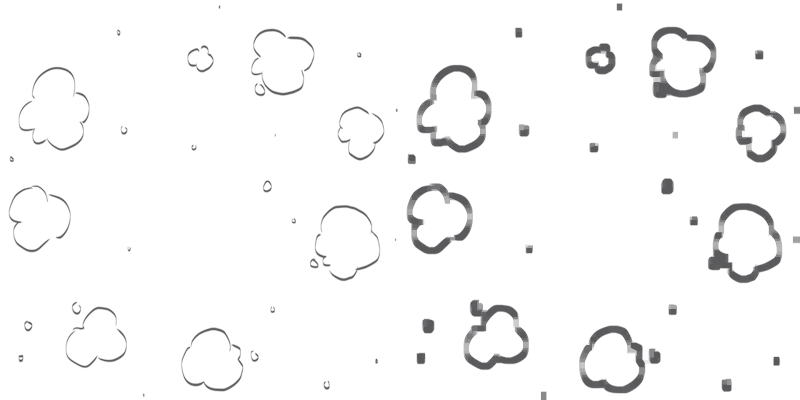

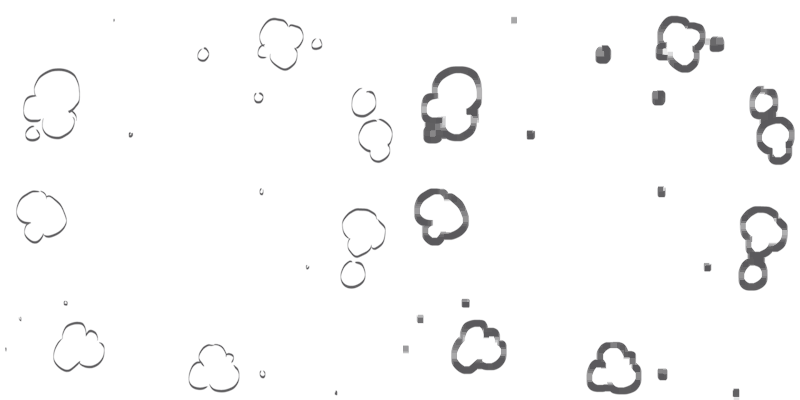

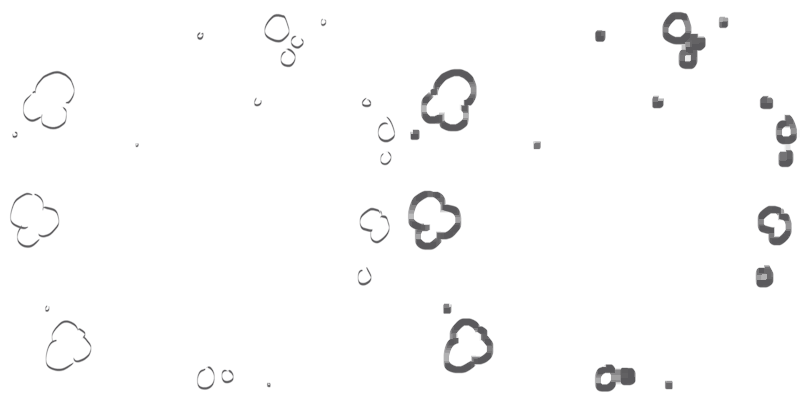

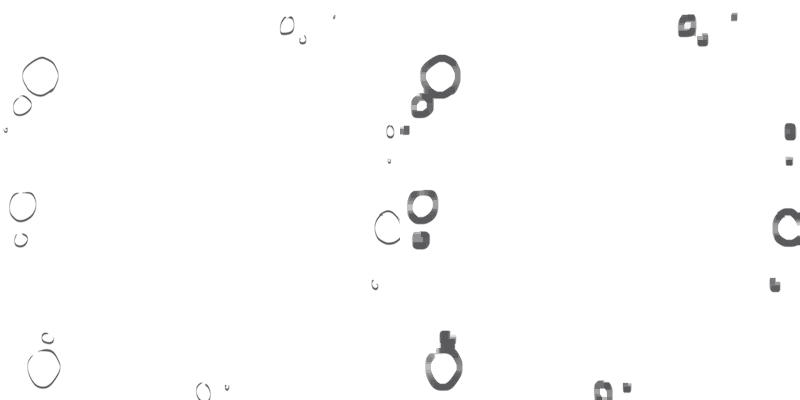

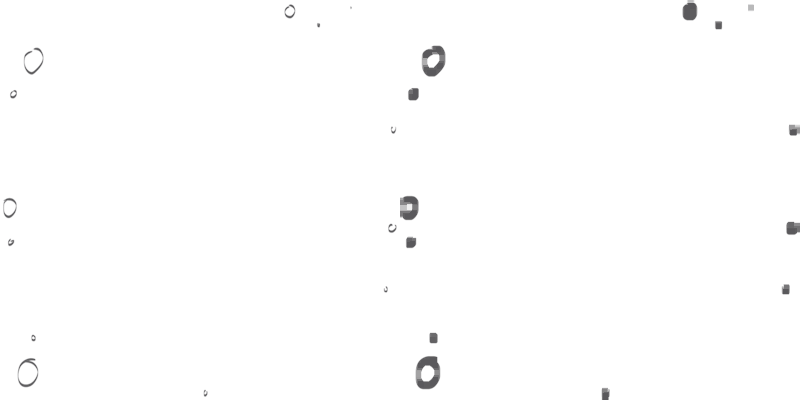

In [43]:
filtered_frames = deepcopy(frames)

filters = [ImageFilter.MinFilter(size=9), ImageFilter.MaxFilter(size=5)]

# Apply filters in series, starting with a copy of the unfiltered frame list
for fltr in filters:
    filtered_frames = [Frame(frame.image.filter(fltr), frame.duration) for frame in filtered_frames]

for f_frame in filtered_frames:

    f_frame.image

# Apply filters in series, starting with a copy of the unfiltered frame list
filtered_frames = deepcopy(frames)
for fltr in filters:
    filtered_frames = [Frame(frame.image.filter(fltr), frame.duration) for frame in filtered_frames]

# test
def resize_concat_horizontally(im_list, resample=Image.BOX):
    # Adapted from: https://note.nkmk.me/en/python-pillow-concat-images/

    cropped_img_list = [img.crop(img.getbbox()) for img in im_list]
    min_height = min(im.height for im in cropped_img_list)
    im_list_resize = [
        im.resize((int(im.width * min_height / im.height), min_height), resample=resample)
        for im in cropped_img_list
    ]
    total_width = sum(im.width for im in im_list_resize)
    dst = Image.new("RGBA", (total_width, min_height))
    pos_x = 0
    for im in im_list_resize:
        dst.paste(im, (pos_x, 0))
        pos_x += im.width
    return dst


for frame, filtered_frame in zip(frames, filtered_frames):
    display(resize_concat_horizontally([frame.image, filtered_frame.image]))

Now, to make the background transparent:

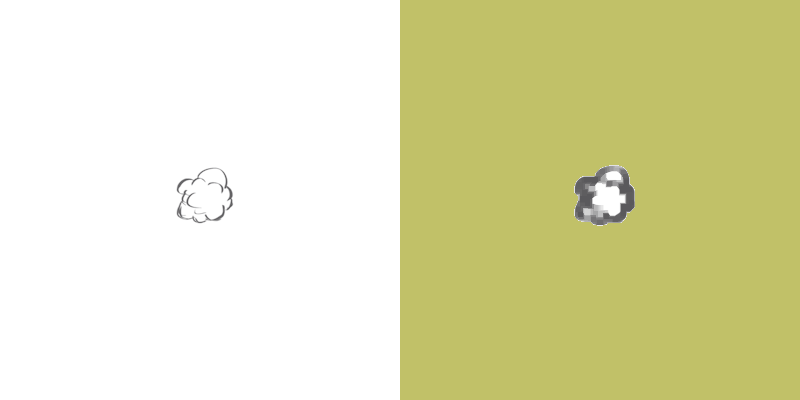

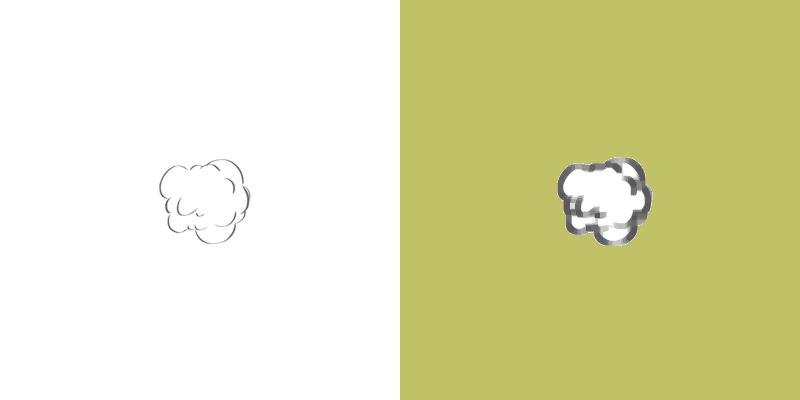

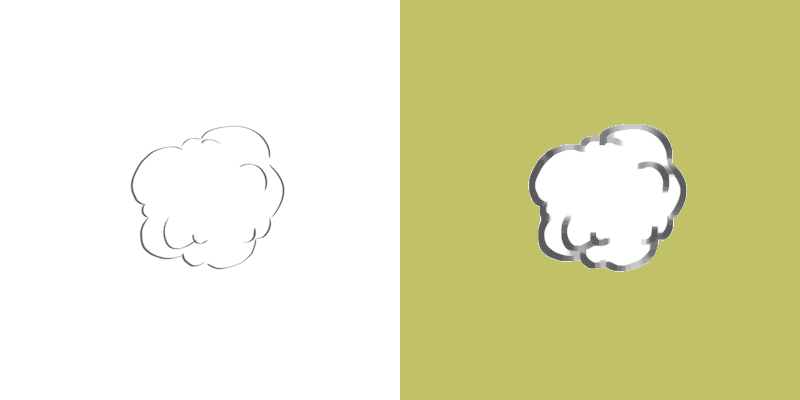

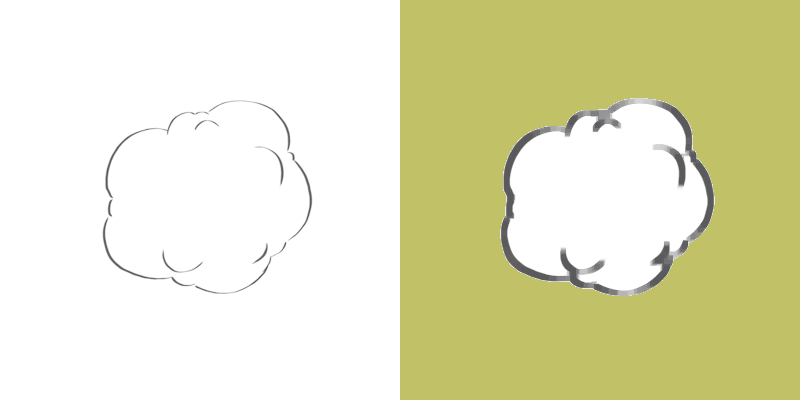

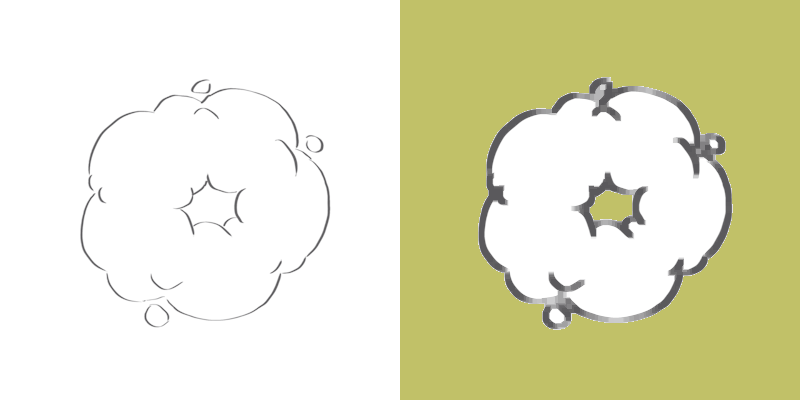

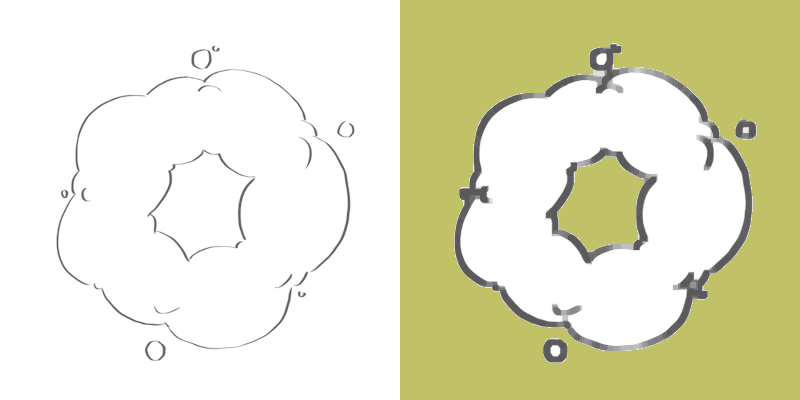

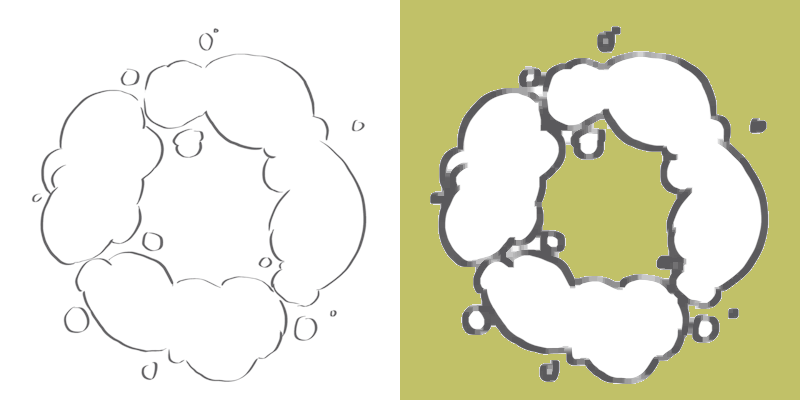

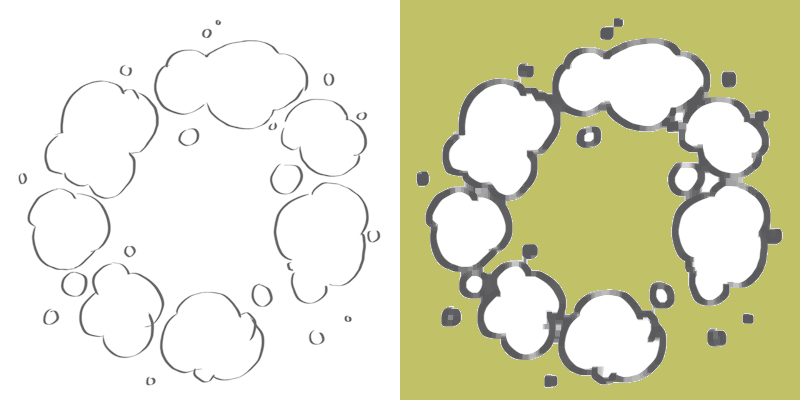

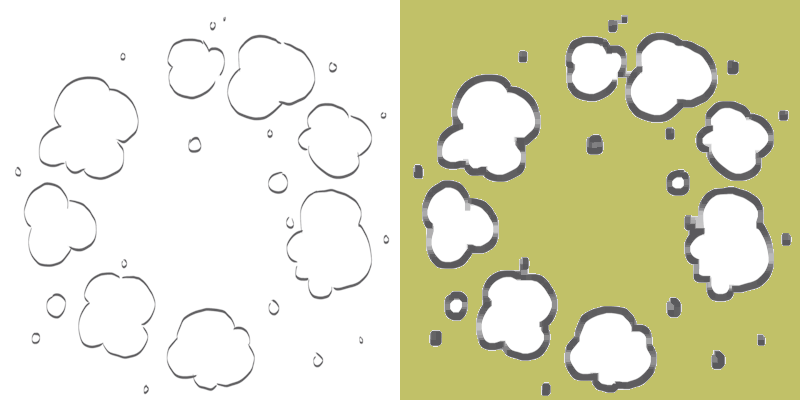

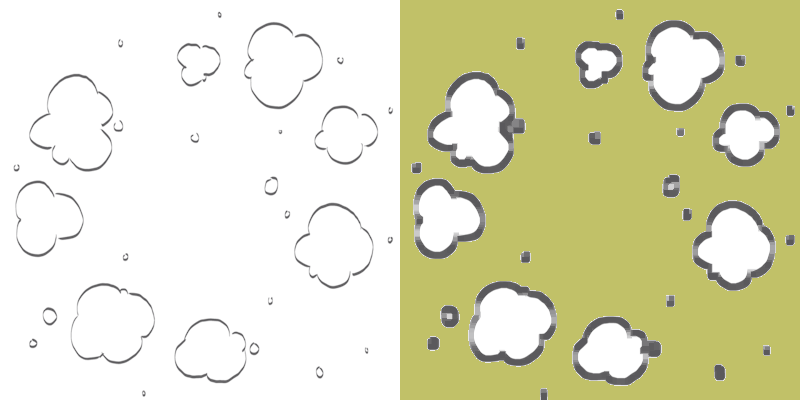

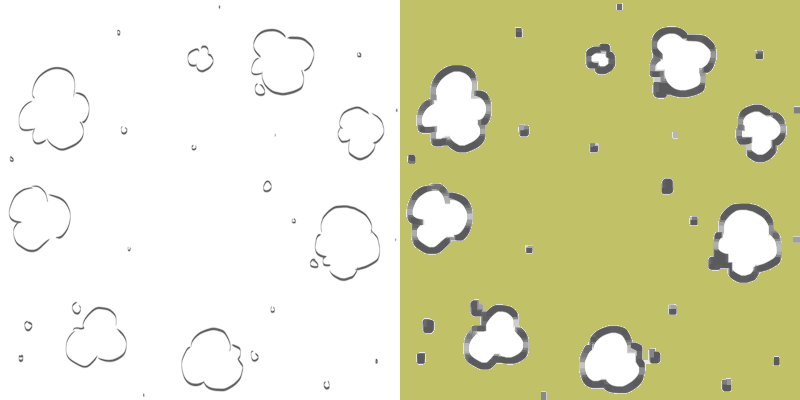

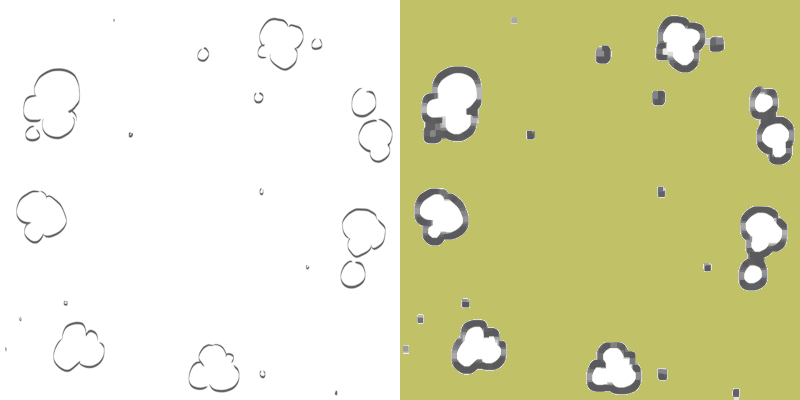

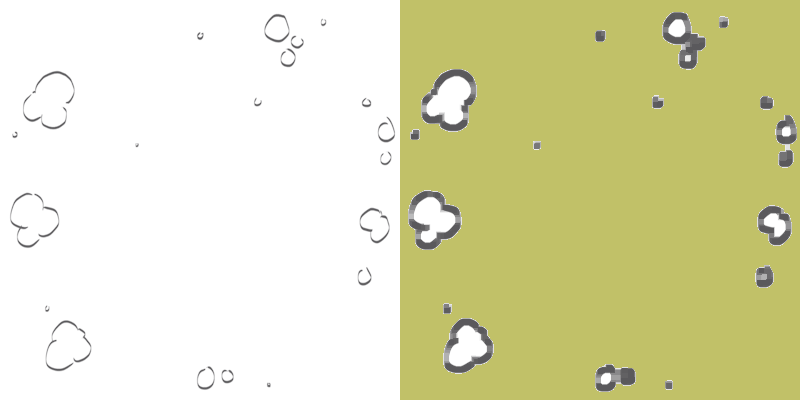

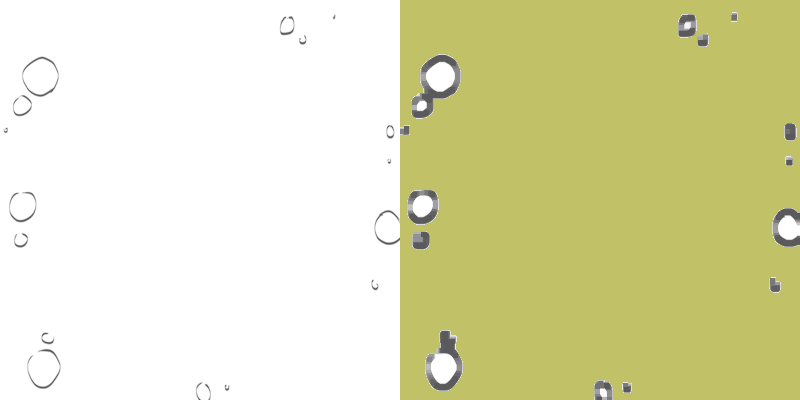

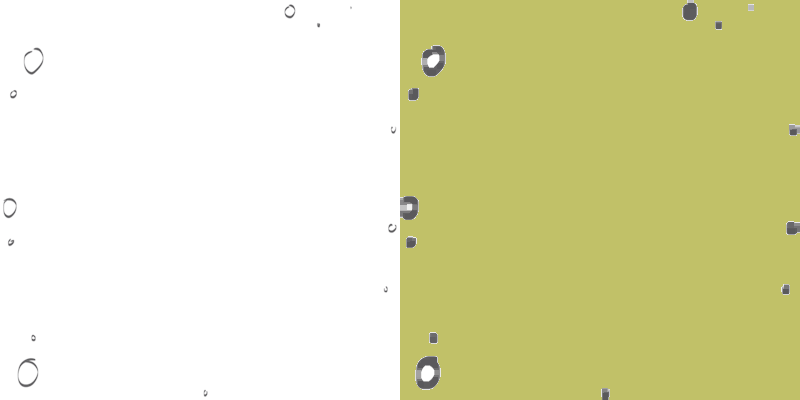

In [44]:
filled_filtered_frames = deepcopy(filtered_frames)
corner_xy = (0, 0)
center_xy = (
    filled_filtered_frames[0].image.width // 2,
    filled_filtered_frames[0].image.height // 2,
)

thresh = 50
for idx, frame in enumerate(filled_filtered_frames):
    ImageDraw.floodfill(frame.image, corner_xy, (0, 0, 0, 0), thresh=thresh)
    if idx > 3:
        ImageDraw.floodfill(frame.image, center_xy, (0, 0, 0, 0), thresh=thresh)

# TEST
test_frames = deepcopy(filtered_frames)
thresh = 50
for idx, frame in enumerate(test_frames):
    ImageDraw.floodfill(frame.image, corner_xy, (150, 150, 0, 150), thresh=thresh)
    if idx > 3:
        ImageDraw.floodfill(frame.image, center_xy, (150, 150, 0, 150), thresh=thresh)

for frame, test_frame in zip(frames, test_frames):
    display(resize_concat_horizontally([frame.image, test_frame.image]))

Re-saving as a GIF, which could be used in arcade:

In [45]:
if should_save:
    durations = [frame.duration for frame in filled_filtered_frames]
    images = [frame.image for frame in filled_filtered_frames]
    filled_filtered_frames[0].image.save(
        MAIN_PATH / "better_poof.gif",
        save_all=True,
        append_images=images[1:],
        optimize=False,
        duration=durations,
        transparency=0,
        disposal=2,
    )

Also save as a series of images in case that doesn't work:

In [46]:
if should_save:
    for idx, frame in enumerate(filled_filtered_frames):
        frame.image.save(
            MAIN_PATH / f"poof{idx+1}.png",
        )

# Create a "lives" HUD image

Imports and general definitions

import os
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace

import numpy as np

In [47]:
from PIL import Image, ImageChops, ImageColor

IMAGE_DIR_PATH = MAIN_IMAGES_PATH / "HUD"

In [48]:
empty_heart_image = Image.open(IMAGE_DIR_PATH / "hudHeart_empty.png")
full_heart_image = Image.open(IMAGE_DIR_PATH / "hudHeart_full.png")


def get_lives_hud(n_max_lives: int, n_lives_left: int):
    n_lives_lost = n_max_lives - n_lives_left
    return resize_concat_horizontally(
        [full_heart_image] * n_lives_left + [empty_heart_image] * n_lives_lost
    )

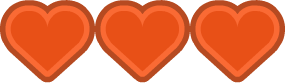

In [49]:
get_lives_hud(3, 3)

# Creating a score image from custom digit images

Imports and general definitions

import os
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace

import numpy as np

In [50]:
from PIL import Image, ImageChops, ImageColor

Create a dictionary where the keys are integers between 0-9 and values are corresponding images:

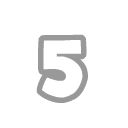

In [51]:
IMAGE_DIR_PATH = MAIN_IMAGES_PATH / "HUD/score"

digit_dict = {
    idx: Image.open(img_path) for idx, img_path in enumerate(IMAGE_DIR_PATH.glob("*.png"))
}

# example/test
display(digit_dict[5])

Defining a function which will display a list of images (digits) side-by-side - a number

In [52]:
def resize_concat_horizontally(im_list, resample=Image.Resampling.BOX):
    # Adapted from: https://note.nkmk.me/en/python-pillow-concat-images/

    cropped_img_list = [img.crop(img.getbbox()) for img in im_list]
    min_height = min(im.height for im in cropped_img_list)
    im_list_resize = [
        im.resize((int(im.width * min_height / im.height), min_height), resample=resample)
        for im in cropped_img_list
    ]
    total_width = sum(im.width for im in im_list_resize)
    dst = Image.new("RGBA", (total_width, min_height))
    pos_x = 0
    for im in im_list_resize:
        dst.paste(im, (pos_x, 0))
        pos_x += im.width
    return dst


# example/test
a = resize_concat_horizontally(list(digit_dict.values()))

Define a function which would return a list of digit images corresponding to an input integer and a digit-to-image dictionary:

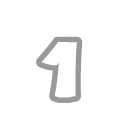

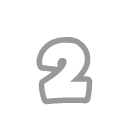

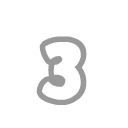

In [53]:
def digit_image_list_from_integer(n: int, digit_dict: dict):
    """Doc."""

    return [digit_dict[int(digit_char)] for digit_char in str(n)]


# example/test
for img in digit_image_list_from_integer(123, digit_dict):
    display(img)

All that's left is to combine the above functions:

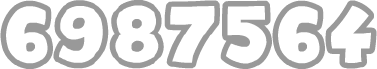

In [54]:
def get_score_image(n: int, digit_img_dir_path: Path):
    """
    Accepts an integer 'n' and a path to a directory containing only
    relevent digit images (sorted - e.g. ending in the corresponding digit)
    and returns an image of the number, made of the digit images supplied.
    """

    digit_dict = {
        idx: Image.open(img_path) for idx, img_path in enumerate(IMAGE_DIR_PATH.glob("*.png"))
    }

    img_list = [digit_dict[int(digit_char)] for digit_char in str(n)]

    return resize_concat_horizontally(img_list)


# example/test
get_score_image(6987564, IMAGE_DIR_PATH)

# Coloring of greyscale pixels

Imports and general definitions

In [55]:
from pathlib import Path

Convert to Numpy and apply color change:

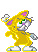

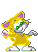

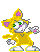

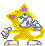

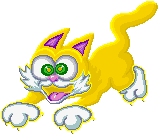

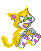

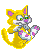

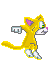

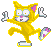

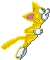

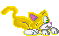

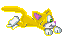

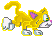

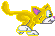

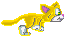

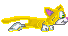

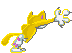

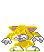

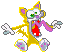

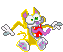

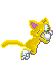

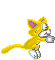

In [56]:
IMAGE_DIR_PATH = MAIN_IMAGES_PATH / "cat"
color = "gold"

for img_path in IMAGE_DIR_PATH.glob("*.png"):
    display(tint_greyscale_pixels(Image.open(img_path), color))